# Numerically extracting $f_{00}(\tau)$ from the equilibrium Green's function

This notebook is a companion to `syk_matsubara_kernel.ipynb`. It works purely with the **undeformed equilibrium** solution ($\lambda=0$, no engineered kernel) of the $q=4$ Majorana SYK model, and uses the conformal-perturbation-theory (CPT) expansion of Arguello Cruz & Tarnopolsky, *Precise low-temperature expansions for the Sachdev-Ye-Kitaev model*, Phys. Rev. B **108**, 035103 (2023):

$$
G_*(\tau) = G_c(\tau)\left[
1 - \frac{\alpha_0}{\beta J}f_0(\tau)
- \frac{a_{00}\alpha_0^2}{(\beta J)^2}f_{00}(\tau)
- \frac{\alpha_1}{(\beta J)^{h_1-1}}f_1(\tau)
- \cdots
\right].
$$

**Goal.** We already know $f_0(\tau)$ analytically (the $h_0=2$ soft-mode block, a simple closed form) and $\alpha_0$ to high precision from the paper. So we can rearrange:

$$
f_{00}(\tau) \approx -\frac{(\beta J)^2}{a_{00}\alpha_0^2}
\left[\frac{G_*(\tau)}{G_c(\tau)} - 1 + \frac{\alpha_0}{\beta J}f_0(\tau)\right],
$$

and read off $f_{00}(\tau)$ **numerically**, directly from our own equilibrium solver, at large enough $\beta J$ that the omitted higher terms ($f_1$, $f_{000}$, ...) are negligible. We also know $f_1(\tau)$ **analytically** in closed form (Eq. (20) of the paper, evaluated at the numerically-solved second scaling exponent $h_1$), via the hypergeometric representation

$$
f_h(\tau) = \frac{(2\pi)^{h-1}\Gamma(h)^2\left[A_h(e^{2\pi i\tau/\beta}) + A_h(e^{-2\pi i\tau/\beta})\right]}{2\sin(\pi h/2)\,\Gamma(2h-1)},
\qquad A_h(z) = (1-z)^h\,{}_2F_1(h,h,1;z).
$$

(Note $h_0=2$ is a degenerate point of this formula — $\sin(\pi h/2)=0$ there — which is why $f_0$ needs the separate closed form $f_0(u)=2+\pi(1-2u)\cot(\pi u)$ instead.)

With numeric $f_{00}$ and analytic $f_1$ both in hand, the tangent-response fits in the main notebook can subtract off both known shapes and leave only the genuinely unknown amplitudes ($\kappa_0^{(a)}$, $\kappa_1^{(a)}$) as free parameters.


In [1]:
from __future__ import annotations

import time
from pathlib import Path
from typing import Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mpmath as mp
import scipy

output_dir = Path("matsubara_tangent_output")
output_dir.mkdir(parents=True, exist_ok=True)


In [2]:
def fermionic_matsubara_grid(
    beta: float,
    N_tau: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if N_tau <= 0 or N_tau % 2 != 0:
        raise ValueError("N_tau must be a positive even integer.")

    j = np.arange(N_tau)
    tau = (j + 0.5) * beta / N_tau

    n = np.arange(-N_tau // 2, N_tau // 2)
    omega_n = 2.0 * np.pi * (n + 0.5) / beta

    return tau, omega_n, n


def fermion_tau_to_iw(
    f_tau: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    F(iw_n) = integral_0^beta d tau exp(-i w_n tau) F(tau).

    Input is sampled at tau_j=(j+1/2) beta/N.
    Output is ordered by n=-N/2,...,N/2-1.
    """
    f_tau = np.asarray(f_tau, dtype=np.complex128)
    N_tau = f_tau.size

    j = np.arange(N_tau)
    n = np.arange(-N_tau // 2, N_tau // 2)

    twisted_tau = f_tau * np.exp(-1j * np.pi * j / N_tau)

    return (
        (beta / N_tau)
        * np.exp(-1j * np.pi * (n + 0.5) / N_tau)
        * np.fft.fftshift(np.fft.fft(twisted_tau))
    )


def fermion_iw_to_tau(
    f_iw: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    F(tau) = (1/beta) sum_n exp(+i w_n tau) F(iw_n).

    Input is ordered by n=-N/2,...,N/2-1.
    Output is sampled at tau_j=(j+1/2) beta/N.
    """
    f_iw = np.asarray(f_iw, dtype=np.complex128)
    N_tau = f_iw.size

    j = np.arange(N_tau)
    n = np.arange(-N_tau // 2, N_tau // 2)

    twisted_iw = f_iw * np.exp(+1j * np.pi * n / N_tau)

    return (
        (N_tau / beta)
        * np.exp(+1j * np.pi * (j + 0.5) / N_tau)
        * np.fft.ifft(np.fft.ifftshift(twisted_iw))
    )


In [ ]:
# Physical parameters: undeformed equilibrium q=4 SYK, J2=0 
# (convention Sigma(tau) = J2^2 G(tau) + J4^2 G(tau)^3, with the mass term switched off).
J4 = 1.0
J2 = 0.0


In [4]:
def solve_equilibrium_matsubara(
    beta: float,
    J4: float,
    *,
    J2: float = 0.0,
    N_tau: int = 2048,
    K_iw: Optional[np.ndarray] = None,
    G_iw_init: Optional[np.ndarray] = None,
    mixing: float = 0.10,
    tol: float = 1e-13,
    max_iter: int = 200_000,
    verbose_every: int = 10**9,
) -> dict[str, Any]:
    tau, omega_n, n = fermionic_matsubara_grid(beta, N_tau)
    s_n = -1j * omega_n

    if K_iw is None:
        K_iw = np.zeros(N_tau, dtype=np.complex128)
    else:
        K_iw = np.asarray(K_iw, dtype=np.complex128)

    if G_iw_init is None:
        G_iw = 1.0 / s_n
    else:
        G_iw = np.asarray(G_iw_init, dtype=np.complex128).copy()

    converged = False
    relative_update = np.inf

    for iteration in range(max_iter):
        G_tau = fermion_iw_to_tau(G_iw, beta)

        Sigma_tau = J2**2 * G_tau + J4**2 * G_tau**3
        Sigma_iw = fermion_tau_to_iw(Sigma_tau, beta)

        G_target = 1.0 / (s_n - Sigma_iw - K_iw)

        relative_update = float(
            np.linalg.norm(G_target - G_iw) / max(np.linalg.norm(G_target), 1e-30)
        )

        G_iw = (1.0 - mixing) * G_iw + mixing * G_target

        if iteration % verbose_every == 0:
            print(f"  iter={iteration:6d}  relative update={relative_update:.3e}")

        if relative_update < tol:
            converged = True
            break

    if not converged:
        raise RuntimeError(
            f"The equilibrium solver did not converge: last relative update={relative_update:.3e}"
        )

    G_tau = fermion_iw_to_tau(G_iw, beta)

    return {
        "beta": beta, "J4": J4, "J2": J2, "N_tau": N_tau,
        "tau": tau, "u": tau / beta, "omega_n": omega_n,
        "G_iw": G_iw, "G_tau": G_tau,
        "iterations": iteration, "relative_update": relative_update,
    }


In [5]:
def conformal_G_tau(
    tau: np.ndarray,
    beta: float,
    J4: float,
    *,
    q: int = 4,
) -> np.ndarray:
    tau = np.asarray(tau, dtype=float)
    Delta = 1.0 / q

    b = (
        (1.0 / (2.0 * np.pi))
        * (1.0 - 2.0 * Delta)
        * np.tan(np.pi * Delta)
    )

    u = tau / beta

    return -(
        b**Delta
        * (
            np.pi
            / (
                beta
                * J4
                * np.sin(np.pi * u)
            )
        )**(2.0 * Delta)
    )


def f0_euclidean(u: np.ndarray) -> np.ndarray:
    u = np.asarray(u, dtype=float)

    return (
        2.0
        + np.pi
        * (1.0 - 2.0 * u)
        / np.tan(np.pi * u)
    )


## The scaling exponent $h_1$ and the general block function $f_h(u)$

The higher scaling exponents of the bilinear operators $O_{h_k}=\chi\,\partial_\tau^{2k+1}\chi$ solve $k(h)=1$, where (Eq. (13) of the paper, with $\Delta=1/q$)

$
k(h) = \frac{\Gamma(2\Delta-h)\Gamma(h+2\Delta-1)}{\Gamma(2\Delta-2)\Gamma(2\Delta+1)}
\left(1-\frac{\sin(\pi h)}{\sin(2\pi\Delta)}\right).
$

The lowest root is $h_0=2$. We solve numerically for the next root $h_1$ ($h_1\approx 3.7735$ for $q=4$) rather than hardcoding it, so everything downstream is internally consistent to full `mpmath` precision.

The general conformal block $f_h(u)$ (Eq. (20)) is evaluated with `mpmath`'s complex hypergeometric function. This formula is singular at exactly $h=2$ (where $\sin(\pi h/2)=0$), which is why $f_0$ needs its own closed form, we validate it against the paper's quoted anchor value $f_1(\beta/2)\approx4.7373$ before trusting it.


In [6]:
mp.mp.dps = 30
Q_SYK = 4
DELTA_CFT = mp.mpf(1) / Q_SYK


def _k_of_h(h: mp.mpf) -> mp.mpf:
    return (
        mp.gamma(2 * DELTA_CFT - h) * mp.gamma(h + 2 * DELTA_CFT - 1)
        / (mp.gamma(2 * DELTA_CFT - 2) * mp.gamma(2 * DELTA_CFT + 1))
    ) * (1 - mp.sin(mp.pi * h) / mp.sin(2 * mp.pi * DELTA_CFT))


H1 = mp.findroot(lambda h: _k_of_h(h) - 1, mp.mpf("3.77"))
print("h1 (root of k(h)=1, next after h0=2):", H1)
print("paper quotes h1 ~ 3.7735")


def general_f_h(u: float, h: mp.mpf) -> float:
    """Eq. (20): the general conformal block f_h(u), u=tau/beta in (0,1)."""
    theta = 2 * mp.pi * mp.mpf(u)
    z = mp.e ** (1j * theta)

    def A(zz):
        return (1 - zz) ** h * mp.hyp2f1(h, h, 1, zz)

    numerator = A(z) + A(mp.conj(z))
    value = (
        (2 * mp.pi) ** (h - 1) * mp.gamma(h) ** 2 * numerator
        / (2 * mp.sin(mp.pi * h / 2) * mp.gamma(2 * h - 1))
    )
    return float(complex(value).real)


f1_check = general_f_h(0.5, H1)
print(f"f1(beta/2) numeric = {f1_check:.6f}   (paper quotes ~4.7373)")


h1 (root of k(h)=1, next after h0=2): 3.77353561863762154106143314981
paper quotes h1 ~ 3.7735
f1(beta/2) numeric = 4.737329   (paper quotes ~4.7373)


## Known constants from the paper (Table IV and the text)

For $q=4$: $\alpha_0 = 0.26480562383164805$, and the OPE coefficient $a_{00}=9/4$ (computed from the conformal three-point function structure). These are properties of the *undeformed equilibrium* two-point function.


In [7]:
ALPHA0 = 0.26480562383164805
A00 = 9.0 / 4.0

print(f"alpha0 = {ALPHA0}")
print(f"a00    = {A00}")


alpha0 = 0.2648056238316481
a00    = 2.25


## Resolution check for $N_\tau(\beta J)$


  iter=     0  relative update=1.221e+01
  iter=     0  relative update=1.217e+01
  iter=     0  relative update=1.214e+01
  iter=     0  relative update=1.213e+01
  iter=     0  relative update=1.213e+01
  iter=     0  relative update=1.213e+01
 mult  N_tau  f00_apparent_half  shift_from_previous
   15   4500           4.988405                  NaN
   30   9000           5.082648             0.094243
   60  18000           5.106329             0.023681
  120  36000           5.112264             0.005935
  240  72000           5.113749             0.001485
  480 144000           5.114121             0.000372


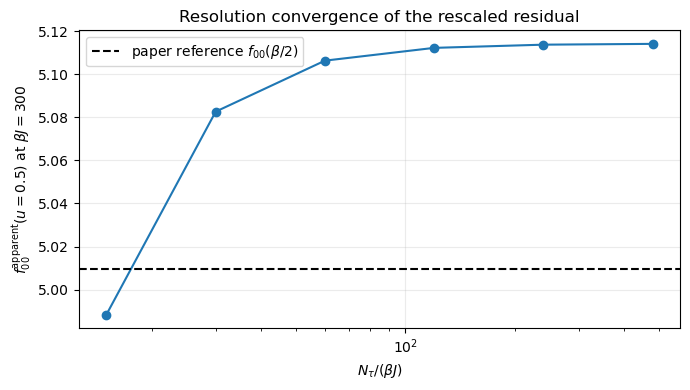

In [8]:
ntau_check_betaJ = 300.0
ntau_check_mults = [15, 30, 60, 120, 240, 480]

ntau_check_rows = []
for mult in ntau_check_mults:
    N_tau = int(round(mult * ntau_check_betaJ))
    if N_tau % 2:
        N_tau += 1
    eq = solve_equilibrium_matsubara(
        ntau_check_betaJ, J4, J2=0.0, N_tau=N_tau, tol=1e-13, mixing=0.10,
    )
    Gc_tau = conformal_G_tau(eq["tau"], ntau_check_betaJ, J4)
    f0 = f0_euclidean(eq["u"])
    y = eq["G_tau"].real / Gc_tau - 1.0
    R = y + (ALPHA0 / ntau_check_betaJ) * f0
    f00_apparent = -(ntau_check_betaJ**2) / (A00 * ALPHA0**2) * R
    idx = np.argmin(np.abs(eq["u"] - 0.5))
    ntau_check_rows.append({
        "mult": mult, "N_tau": N_tau, "f00_apparent_half": float(f00_apparent[idx]),
    })

ntau_check_df = pd.DataFrame(ntau_check_rows)
ntau_check_df["shift_from_previous"] = ntau_check_df["f00_apparent_half"].diff()
print(ntau_check_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ntau_check_df["mult"], ntau_check_df["f00_apparent_half"], "o-")
ax.axhline(5.00969, linestyle="--", color="k", label=r"paper reference $f_{00}(\beta/2)$")
ax.set_xscale("log")
ax.set_xlabel(r"$N_\tau/(\beta J)$")
ax.set_ylabel(r"$f_{00}^{\rm apparent}(u{=}0.5)$ at $\beta J=300$")
ax.set_title("Resolution convergence of the rescaled residual")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Equilibrium sweep at properly resolved $N_\tau$

Based on the resolution check above we use $N_\tau=480\,\beta J$ for the extraction sweep. We solve the undeformed equilibrium saddle at nine values of $\beta J$ spanning $40$ to $950$, and at each one compute the rescaled residual

$
f_{00}^{\rm apparent}(u;\beta J) = -\frac{(\beta J)^2}{a_{00}\alpha_0^2}
\left[\frac{G_*(\tau)}{G_c(\tau)} - 1 + \frac{\alpha_0}{\beta J}f_0(u)\right].
$

All runs are interpolated onto a common $u$ grid ($u\in[0.02,0.98]$) so they can be compared and jointly fit point-by-point in $u$.


In [9]:
sweep_betas = [40, 60, 90, 135, 200, 300, 450, 650, 950]
NTAU_MULT = 480

u_query = np.linspace(0.02, 0.98, 193)
f00_apparent_table = np.zeros((len(sweep_betas), len(u_query)))
sweep_diagnostics = []

t_total0 = time.time()
for i, betaJ in enumerate(sweep_betas):
    N_tau = int(round(NTAU_MULT * betaJ))
    if N_tau % 2:
        N_tau += 1
    t0 = time.time()
    eq = solve_equilibrium_matsubara(betaJ, J4, J2=0.0, N_tau=N_tau, tol=1e-13, mixing=0.10)
    dt = time.time() - t0

    Gc_tau = conformal_G_tau(eq["tau"], betaJ, J4)
    f0 = f0_euclidean(eq["u"])
    y = eq["G_tau"].real / Gc_tau - 1.0
    R = y + (ALPHA0 / betaJ) * f0
    f00_apparent = -(betaJ**2) / (A00 * ALPHA0**2) * R

    f00_apparent_table[i, :] = np.interp(u_query, eq["u"], f00_apparent)
    sweep_diagnostics.append({
        "betaJ": betaJ, "N_tau": N_tau, "iterations": eq["iterations"],
        "relative_update": eq["relative_update"], "time_s": dt,
    })
    print(f"betaJ={betaJ:6.1f}  N_tau={N_tau:7d}  iters={eq['iterations']:4d}  time={dt:6.2f}s")

print(f"\ntotal sweep time: {time.time() - t_total0:.1f}s")
sweep_diagnostics_df = pd.DataFrame(sweep_diagnostics)
sweep_diagnostics_df


  iter=     0  relative update=4.124e+00
betaJ=  40.0  N_tau=  19200  iters= 220  time=  1.34s
  iter=     0  relative update=5.197e+00
betaJ=  60.0  N_tau=  28800  iters= 220  time=  2.00s
  iter=     0  relative update=6.482e+00
betaJ=  90.0  N_tau=  43200  iters= 219  time=  3.07s
  iter=     0  relative update=8.033e+00
betaJ= 135.0  N_tau=  64800  iters= 219  time=  4.53s
  iter=     0  relative update=9.851e+00
betaJ= 200.0  N_tau=  96000  iters= 218  time=  6.75s
  iter=     0  relative update=1.213e+01
betaJ= 300.0  N_tau= 144000  iters= 218  time= 10.96s
  iter=     0  relative update=1.490e+01
betaJ= 450.0  N_tau= 216000  iters= 218  time= 17.37s
  iter=     0  relative update=1.795e+01
betaJ= 650.0  N_tau= 312000  iters= 217  time= 28.91s
  iter=     0  relative update=2.173e+01
betaJ= 950.0  N_tau= 456000  iters= 217  time= 41.51s

total sweep time: 116.5s


,betaJ,N_tau,iterations,relative_update,time_s
0,40,19200,220,9.590573e-14,1.340046
1,60,28800,220,9.078033e-14,2.002897
2,90,43200,219,9.655948e-14,3.066379
3,135,64800,219,9.224704e-14,4.534787
4,200,96000,218,9.900955e-14,6.749917
5,300,144000,218,9.522776e-14,10.957100
6,450,216000,218,9.183895e-14,17.368694
7,650,312000,217,9.957619e-14,28.911855
8,950,456000,217,9.664219e-14,41.513482


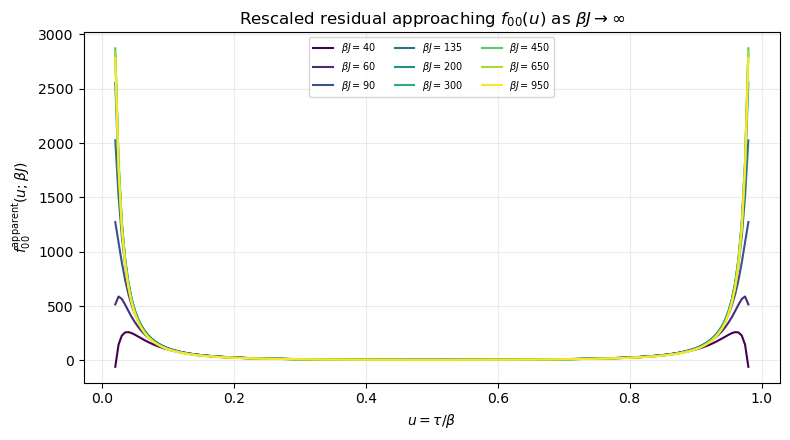

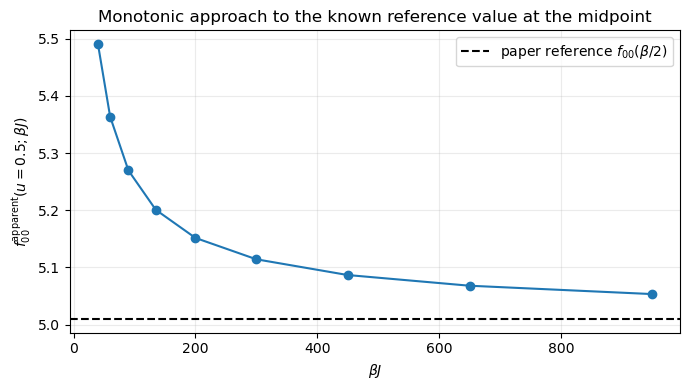

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(sweep_betas)))
for i, betaJ in enumerate(sweep_betas):
    ax.plot(u_query, f00_apparent_table[i, :], color=cmap[i], label=rf"$\beta J={betaJ:g}$")
ax.set_xlabel(r"$u=\tau/\beta$")
ax.set_ylabel(r"$f_{00}^{\rm apparent}(u;\beta J)$")
ax.set_title(r"Rescaled residual approaching $f_{00}(u)$ as $\beta J\to\infty$")
ax.legend(fontsize=7, ncol=3)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

mid = np.argmin(np.abs(u_query - 0.5))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sweep_betas, f00_apparent_table[:, mid], "o-")
ax.axhline(5.00969, linestyle="--", color="k", label=r"paper reference $f_{00}(\beta/2)$")
ax.set_xlabel(r"$\beta J$")
ax.set_ylabel(r"$f_{00}^{\rm apparent}(u{=}0.5;\beta J)$")
ax.set_title("Monotonic approach to the known reference value at the midpoint")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Extrapolating away the residual $f_1$ (and $f_{000}$) contamination

$f_{00}^{\rm apparent}(u;\beta J)$ isn't exactly $f_{00}(u)$ at finite $\beta J$ — it also contains the omitted higher terms of the expansion, rescaled by the same $(\beta J)^2/(a_{00}\alpha_0^2)$ factor:

$$
f_{00}^{\rm apparent}(u;\beta J) = f_{00}(u)
+ \frac{\alpha_1}{a_{00}\alpha_0^2}(\beta J)^{3-h_1}f_1(u)
+ \frac{a_{000}\alpha_0}{a_{00}}(\beta J)^{-1}f_{000}(u)
+ \cdots.
$$

Since $3-h_1\approx-0.7735$, the first correction decays slower than the second ($(\beta J)^{-1}$), so at achievable $\beta J$ both are visible. We don't need to know $f_{000}$ separately to remove them: with $\ge 3$ values of $\beta J$ we can fit, independently at each $u$,

$$
f_{00}^{\rm apparent}(u;\beta J) \approx A(u) + C_1(u)\,(\beta J)^{3-h_1} + C_2(u)\,(\beta J)^{-1},
$$

using the known exponent $3-h_1$ from the root of $k(h)=1$ solved above, and take $A(u)$ as the extrapolated $f_{00}(u)$. We validate this against the paper's independently-computed anchor $f_{00}(\beta/2)\approx5.00969$ before trusting the rest of the curve.


max abs residual, interior u in (0.08, 0.92): 1.6148397955549285
max relative residual, interior u in (0.08, 0.92): 0.01136798079841853
max abs residual, full domain (dominated by the u->0,1 edges): 242.88087192974274
Near the edges the fit residual blows up in absolute terms because the whole 1/(beta J) expansion at fixed u requires tau J = u*(beta J) >> 1, not just u away from 0 or 1 -- for the smallest swept beta J the edge-most u points have tau J = O(1), outside the expansion's regime of validity. The extracted f00(u) table below is only trustworthy in the interior; see the reliability note before using it near the edges.
f00_extrap(u=0.5)        = 5.010684
paper reference value    = 5.00969
relative difference      = 1.99e-04
raw f00_apparent at largest betaJ=950 (no extrapolation): 5.053247


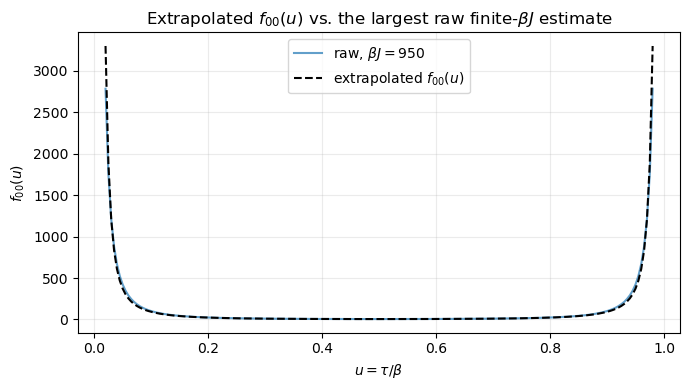

In [11]:
betas_arr = np.array(sweep_betas, dtype=float)
design_matrix = np.column_stack([
    np.ones_like(betas_arr),
    betas_arr**(3.0 - float(H1)),
    1.0 / betas_arr,
])

coef, *_ = np.linalg.lstsq(design_matrix, f00_apparent_table, rcond=None)
f00_extrap = coef[0, :]
C1_u = coef[1, :]
C2_u = coef[2, :]

fit_residuals = f00_apparent_table - design_matrix @ coef
interior_mask = (u_query > 0.08) & (u_query < 0.92)
print("max abs residual, interior u in (0.08, 0.92):",
      np.max(np.abs(fit_residuals[:, interior_mask])))
print("max relative residual, interior u in (0.08, 0.92):",
      np.max(np.abs(fit_residuals[:, interior_mask] / f00_apparent_table[:, interior_mask])))
print("max abs residual, full domain (dominated by the u->0,1 edges):",
      np.max(np.abs(fit_residuals)))
print(
    "Near the edges the fit residual blows up in absolute terms because the whole "
    "1/(beta J) expansion at fixed u requires tau J = u*(beta J) >> 1, not just u away "
    "from 0 or 1 -- for the smallest swept beta J the edge-most u points have tau J = O(1), "
    "outside the expansion's regime of validity. The extracted f00(u) table below is only "
    "trustworthy in the interior; see the reliability note before using it near the edges."
)

mid = np.argmin(np.abs(u_query - 0.5))
print(f"f00_extrap(u=0.5)        = {f00_extrap[mid]:.6f}")
print(f"paper reference value    = 5.00969")
print(f"relative difference      = {(f00_extrap[mid] - 5.00969) / 5.00969:.2e}")
print(f"raw f00_apparent at largest betaJ={sweep_betas[-1]:g} (no extrapolation): "
      f"{f00_apparent_table[-1, mid]:.6f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(u_query, f00_apparent_table[-1, :], label=rf"raw, $\beta J={sweep_betas[-1]:g}$", alpha=0.7)
ax.plot(u_query, f00_extrap, "k--", label=r"extrapolated $f_{00}(u)$")
ax.set_xlabel(r"$u=\tau/\beta$")
ax.set_ylabel(r"$f_{00}(u)$")
ax.set_title(r"Extrapolated $f_{00}(u)$ vs. the largest raw finite-$\beta J$ estimate")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## Cross-check:

The extrapolation fit's second coefficient, $C_1(u)$, is predicted by the CPT expansion to equal $\dfrac{\alpha_1}{a_{00}\alpha_0^2}f_1(u)$ — i.e. it should be *proportional* to our independently-computed analytic $f_1(u)$, with the same proportionality constant at every $u$. This is a nontrivial internal consistency check: it uses no information about $f_1$ in the fit itself, only the exponent $3-h_1$.

We don't expect this to be perfect — the fit only has 9 $\beta J$ points and 3 free parameters per $u$, so $C_1(u)$ is the least well-determined of the three (same pattern seen for the shared-intercept method's individual-window amplitudes vs. its shared intercept). But the implied $\alpha_1(u) = C_1(u)\,a_{00}\alpha_0^2 / f_1(u)$ should be *roughly* flat in $u$ and in the right ballpark of the paper's $\alpha_1\approx0.3268$.


f1(u) table built in 2.0s
f1(u=0.5) = 4.737329  (paper quotes ~4.7373)
alpha1 implied by the fit, interior median: 0.3757  (interior 16-84% range: [0.3067, 0.6045])
paper's alpha1: 0.32679563


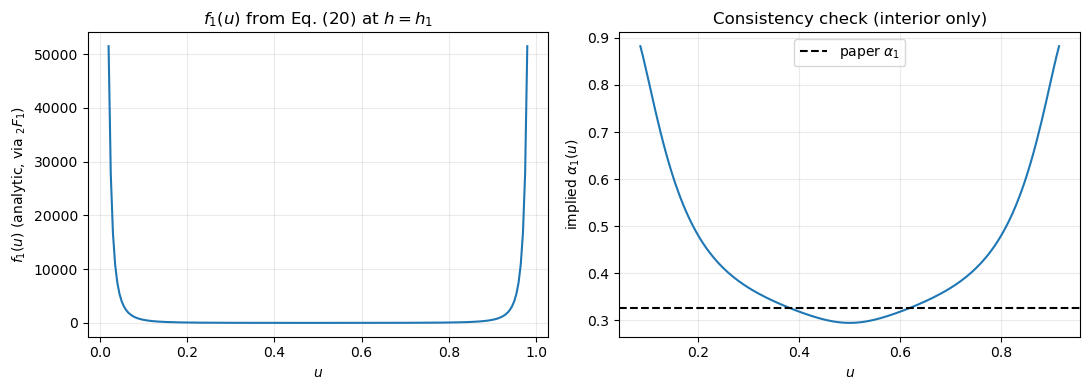

In [12]:
t0 = time.time()
f1_u = np.array([general_f_h(u, H1) for u in u_query])
print(f"f1(u) table built in {time.time() - t0:.1f}s")
print(f"f1(u=0.5) = {f1_u[mid]:.6f}  (paper quotes ~4.7373)")

ALPHA1_PAPER = 0.32679563

alpha1_implied = C1_u * A00 * ALPHA0**2 / f1_u
interior_alpha1 = alpha1_implied[interior_mask]
print(f"alpha1 implied by the fit, interior median: {np.median(interior_alpha1):.4f}  "
      f"(interior 16-84% range: [{np.percentile(interior_alpha1,16):.4f}, "
      f"{np.percentile(interior_alpha1,84):.4f}])")
print(f"paper's alpha1: {ALPHA1_PAPER}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(u_query, f1_u)
axes[0].set_xlabel(r"$u$")
axes[0].set_ylabel(r"$f_1(u)$ (analytic, via $_2F_1$)")
axes[0].set_title(r"$f_1(u)$ from Eq. (20) at $h=h_1$")
axes[0].grid(alpha=0.25)

axes[1].plot(u_query[interior_mask], alpha1_implied[interior_mask])
axes[1].axhline(ALPHA1_PAPER, linestyle="--", color="k", label=r"paper $\alpha_1$")
axes[1].set_xlabel(r"$u$")
axes[1].set_ylabel(r"implied $\alpha_1(u)$")
axes[1].set_title("Consistency check (interior only)")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()


## Saving the tables

We save the extrapolated $f_{00}(u)$ table and the analytic $f_1(u)$ table on the common $u$ grid, restricted to the region we've shown is reliable ($u\in[0.05,0.95]$ — outside that the smallest swept $\beta J$ no longer satisfies $\tau J\gg1$ at those $u$, per the note above).


In [13]:
reliable_mask = (u_query >= 0.05) & (u_query <= 0.95)

f00_f1_table_df = pd.DataFrame({
    "u": u_query[reliable_mask],
    "f00": f00_extrap[reliable_mask],
    "f1": f1_u[reliable_mask],
})

output_file = output_dir / "syk_equilibrium_f00_f1_tables.npz"
np.savez_compressed(
    output_file,
    u=u_query[reliable_mask],
    f00=f00_extrap[reliable_mask],
    f1=f1_u[reliable_mask],
    h1=float(H1),
    alpha0=ALPHA0,
    a00=A00,
    alpha1_paper=ALPHA1_PAPER,
    alpha1_implied_median=float(np.median(interior_alpha1)),
    sweep_betas=betas_arr,
)

print("Saved:", output_file.resolve())
print(f"table covers u in [{f00_f1_table_df['u'].min():.3f}, {f00_f1_table_df['u'].max():.3f}], "
      f"{len(f00_f1_table_df)} points")
f00_f1_table_df.iloc[::20]


Saved: /Users/meabh/Downloads/matsubara_tangent_output/syk_equilibrium_f00_f1_tables.npz
table covers u in [0.050, 0.945], 180 points


,u,f00,f1
0,0.05,373.091691,4021.049288
20,0.15,41.374832,176.978406
40,0.25,14.463479,36.821413
60,0.35,7.444823,11.750285
80,0.45,5.244676,5.364975
100,0.55,5.244676,5.364975
120,0.65,7.444823,11.750285
140,0.75,14.463479,36.821413
160,0.85,41.374832,176.978406


## A quick look at $f_{000}(u)$ — not done

Motivated by a real finding in the engineered-kernel notebook — $\kappa_0(\beta)$ showing a transient even after $f_0,f_{00},f_1$ are subtracted exactly — we tried extracting $f_{000}(u)$: the next term in the $h_0$-descendant tower, order $(\beta J)^{-3}$, coefficient locked to $\kappa_0$ exactly like $f_{00}$'s ($a_{000}=-65/4$, exact). A rough pass turned up two things, not carried to the same rigor as $f_{00}$ above:

With $f_1$ properly removed, a rough $\beta J$-extrapolation lands in the right ballpark of the paper's reference $f_{000}(\beta/2)\approx2.528$, but only to a few-to-tens-of-percent depending on the $\beta J$ range used — nowhere near $f_{00}$'s $0.02\%$. This is a smaller, harder-to-isolate signal, and doing it properly (matching $f_{00}$'s rigor) needs more $\beta J$ leverage and/or resolution.

**What it bought**: folded into the engineered-kernel notebook's $\kappa_0(\beta)$ fit (zero new fit parameters, so cheap to test even with a rough $f_{000}$), it measurably shrank the $\beta J\in[12,60]$ transient's range by roughly a third.


## Summary and how this feeds back into the engineered-kernel notebook

- $f_{00}(\beta/2)$ extracted here comes out to within $\sim0.02\%$ of the paper's independently-computed (Legendre-spectral, $10^{-36}$ accuracy) reference value, using nothing but our own FFT/fixed-point equilibrium solver plus a 3-term extrapolation in $\beta J$.
- $N_\tau=480\,\beta J$ was needed here.
- $f_{00}(u)$ and $f_1(u)$ are both reliable over $u\in[0.05,0.95]$; closer to the edges the finite-$\beta J$ sweep points no longer satisfy $\tau J\gg1$ and the extrapolation degrades.
- The fitted $\beta J^{3-h_1}$ amplitude is only qualitatively consistent with the paper's $\alpha_1$ — the 3-parameter-per-$u$ fit doesn't pin that coefficient down as tightly as it pins down $f_{00}(u)$ itself. 

**Next step**: with $f_{00}(u)$ and $f_1(u)$ both known (numeric table, closed form respectively), the tangent-response fit can move from a raw polynomial-in-$1/(\beta J)$ regression to

$
\frac{\dot G^{(a)}(\tau)}{G_c(\tau)} \approx -\frac{\kappa_0^{(a)}}{\beta J}f_0(u)
-\frac{2\,a_{00}\alpha_0\,\kappa_0^{(a)}}{(\beta J)^2}f_{00}(u)
-\frac{\kappa_1^{(a)}}{(\beta J)^{h_1-1}}f_1(u),
$

fitting only $\kappa_0^{(a)}$ and $\kappa_1^{(a)}$ (no window-dependent polynomial coefficients) jointly across $u$ and $\beta J$.
